# A Practical Example Using BO to Optimise Molecules

Use the RDKit QED score as the oracle objective to maximize drug-likeness.

Use the ZINC dataset as the search space for plausible molecules.

In [1]:
import tarfile
import random
from functools import lru_cache
from rdkit import Chem
from rdkit.Chem import QED


def load_zinc_smiles(zinc_file="examples/Molecule/zinc.txt.gz"):
    with tarfile.open(zinc_file, "r:gz") as tar:
        if (member := tar.extractfile("zinc.txt")) is not None:
            content = member.read().decode("utf-8").splitlines()
            return content
        else:
            raise FileNotFoundError("Error: zinc.txt not found in the archive")


def objective(smiles: str, invalid_score: float = -1) -> float:
    """
    QED objective function for molecular optimization.
    Returns QED score (0-1) - maximize this value.
    Penalizes invalid SMILES with a score of 0.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return invalid_score  # Invalid SMILES = worst possible score
    return QED.qed(mol)


@lru_cache(maxsize=1)  # Use LRU cache to avoid recomputing the subset on every call
def load_challenging_zinc_subset(
    high_qed_threshold: float = 0.25,
    keep_high_fraction: float = 0.1,
) -> list[str]:
    """
    high_qed_threshold is interpreted as a top-fraction percentile.
    Example: 0.25 means molecules in the top 25% QED scores are 'high-QED'.
    """
    if not (0 < high_qed_threshold <= 1):
        raise ValueError("high_qed_threshold must be in (0, 1].")

    smiles_list = load_zinc_smiles()

    scored = []
    for i, smi in enumerate(smiles_list, start=1):
        score = objective(smi)
        scored.append((smi, score))
        print(
            f"Processed molecule {i}/{len(smiles_list)} to create a challenging subset.",
            end="\r",
        )

    sorted_scores = sorted(score for _, score in scored)
    cutoff_index = min(
        len(sorted_scores) - 1,
        max(0, int((1 - high_qed_threshold) * len(sorted_scores))),
    )
    qed_cutoff = sorted_scores[cutoff_index]

    high_qed_smiles = []
    other_smiles = []
    for smi, score in scored:
        if score >= qed_cutoff:
            high_qed_smiles.append(smi)
        else:
            other_smiles.append(smi)

    rng = random.Random(0)
    rng.shuffle(high_qed_smiles)
    rng.shuffle(other_smiles)

    keep_n_high = max(1, int(len(high_qed_smiles) * keep_high_fraction)) if high_qed_smiles else 0
    subset = other_smiles + high_qed_smiles[:keep_n_high]
    rng.shuffle(subset)

    print(
        f"Challenging subset built: {len(subset)} molecules, "
        f"top {high_qed_threshold:.2%} starts at QED >= {qed_cutoff:.4f}, "
        f"kept {keep_n_high}/{len(high_qed_smiles)} high-QED molecules."
    )
    return subset

if __name__ == "__main__":
    subset = load_challenging_zinc_subset()
    print(f"Loaded challenging subset with {len(subset)} molecules.")
    del subset


Challenging subset built: 193327 molecules, top 25.00% starts at QED >= 0.8386, kept 6236/62364 high-QED molecules.
Loaded challenging subset with 193327 molecules.


In [2]:
# type: ignore

from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski


descriptor_map = {
    "molecular_weight": Descriptors.MolWt,  
    "logp": Descriptors.MolLogP,
    "tpsa": Descriptors.TPSA,
    "num_h_bond_donors": Lipinski.NumHDonors,
    "num_h_bond_acceptors": Lipinski.NumHAcceptors,
    "heavy_atom_count": Descriptors.HeavyAtomCount,
    "num_aromatic_rings": Descriptors.NumAromaticRings,
    "ring_count": Descriptors.RingCount,
    "num_rotatable_bonds": Descriptors.NumRotatableBonds,
    "num_heteroatoms": Descriptors.NumHeteroatoms
}


def calculate_descriptor_vector(smiles: str) -> list[float]:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:  # Invalid SMILES, return None
        return None
    return [func(mol) for func in descriptor_map.values()]


N_DESCRIPTORS = len(descriptor_map)



if __name__ == "__main__":
    test_smiles = "CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1"
    descriptor_vector = calculate_descriptor_vector(test_smiles)
    if descriptor_vector is not None:
        for name, value in zip(descriptor_map.keys(), descriptor_vector):
            print(f"{name}: {value}")

molecular_weight: 325.38300000000004
logp: 5.050600000000004
tpsa: 42.24
num_h_bond_donors: 1
num_h_bond_acceptors: 2
heavy_atom_count: 24
num_aromatic_rings: 3
ring_count: 3
num_rotatable_bonds: 3
num_heteroatoms: 4


## Random Search Baseline

In [3]:
# Random Search Baseline
import random
import numpy as np

def run_random_search(total_budget: int):
    search_space = load_challenging_zinc_subset()

    INVALID_SCORE = -1

    random_smiles = random.sample(search_space, total_budget)
    random_scores = [objective(smi, INVALID_SCORE) for smi in random_smiles]

    best_idx = np.argmax(random_scores)
    print(f"Random Search Best: QED = {random_scores[best_idx]:.4f}, SMILES = {random_smiles[best_idx]}")

    return random_smiles, random_scores


## Bayesian Optimisation Based on Gpytorch

1. The search space is all molecules in the ZINC dataset.
2. Establish Gpytorch Model with Descriptor Features
3. Surrogate: SMILES ---> Descriptor Vector ---(GP)---> Objective
4. Acquisition Function (AF): use UCB acquisition function
5. Acquisition Optimiser: Since the ZINC dataset has a very large number of potential molecules, it is not possible to compute the AF on all of them---i.e. to compute the descriptor on all of them. Therefore, we implement a simple alternative: *In each iteration, sample a samll subset of plausible molecules, and only optimise AF in this subset.*


In [4]:
import random
import torch
import gpytorch


class GPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


class SurrogateModel:

    def __init__(self, invalid_score: float = -1, device="auto"):
        if device == "auto":
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)
        self.gp: GPModel | None = None
        self.feature = calculate_descriptor_vector
        self.invalid_score = invalid_score

        self._train_x: list[list[float]] = []
        self._train_y: list[float] = []

    def add_data(self, smiles: str, y: float):
        vec = self.feature(smiles)
        if vec is not None:
            self._train_x.append(vec)
            self._train_y.append(y)

    def fit(self, grad_step: int = 100):
        device = self.device
        train_x = torch.tensor(self._train_x, device=device, dtype=torch.float32)
        train_y = torch.tensor(self._train_y, device=device, dtype=torch.float32)
        if self.gp is None:
            likelihood = gpytorch.likelihoods.GaussianLikelihood()
            self.gp = GPModel(train_x, train_y, likelihood).to(device)
        else:
            self.gp.set_train_data(train_x, train_y, strict=False)
            likelihood = self.gp.likelihood
            assert likelihood is not None

        self.gp.train()
        likelihood.train()

        optimizer = torch.optim.Adam(self.gp.parameters(), lr=0.1)
        mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, self.gp)
        for _ in range(grad_step):
            optimizer.zero_grad()
            output = self.gp(train_x)
            loss = -mll(output, train_y)  # type:ignore
            loss.backward()
            optimizer.step()
    
    def __call__(self, smiles_list: list[str]):
        if self.gp is None:
            raise ValueError("Model not trained yet")
        
        features = torch.zeros((len(smiles_list), N_DESCRIPTORS),
                               device=self.device, dtype=torch.float32)
        invalid = torch.zeros(len(smiles_list),
                              device=self.device, dtype=torch.bool)
        for i, smi in enumerate(smiles_list):
            if (feature := self.feature(smi)) is not None:
                features[i] = torch.tensor(feature)
            else:
                invalid[i] = True

        self.gp.eval()
        assert self.gp.likelihood is not None
        self.gp.likelihood.eval()
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            pred = self.gp.likelihood(self.gp(features))
            mu = pred.mean.clone()
            sigma = pred.stddev.clone()
        
        # override prediction over invalid SMILES to a fixed low score and zero uncertainty
        mu[invalid] = self.invalid_score
        sigma[invalid] = 0.0

        return mu, sigma
        

def acqusition_ucb(smiles_list: list[str], surrogate: SurrogateModel, beta: float = 2.0):
    mu, sigma = surrogate(smiles_list)
    scores = mu + beta * sigma
    return scores


In [5]:
import matplotlib.pyplot as plt


def run_bo_descriptor(total_budget: int, n_init: int | None = None, batch_size: int = 1,
                      n_acq: int = 50000, grad_step: int = 50):
    search_space = load_challenging_zinc_subset()

    if n_init is None:
        n_init = int(0.2 * total_budget)  # default to 10% of the budget for initialization
    
    INVALID_SCORE = -1  # For QED, valid scores are in [0,1], so -1 is a safe choice for invalid molecules

    # Initialization: randomly sample N_init molecules from the search space and evaluate their scores
    surrogate = SurrogateModel(invalid_score=INVALID_SCORE)
    xs_init = random.sample(search_space, n_init)
    ys_init = [objective(smi, INVALID_SCORE) for smi in xs_init]
    for x, y in zip(xs_init, ys_init):
        surrogate.add_data(x, y)
        print(f"Initiazation: QED = {y:.4f}, Molecule = {x}")

    xs = xs_init.copy(); ys = ys_init.copy()

    # the BO loop
    for n in range(n_init, total_budget, batch_size):
        # fit surrogate model
        surrogate.fit(grad_step=grad_step)

        # Acquisition: sample n_acq candidates, evaluate acquisition function, and select the best one
        candidates = random.sample(search_space, n_acq)
        scores = acqusition_ucb(candidates, surrogate, beta=2)  # linearly decay beta from 2 to 0
        k = min(batch_size, total_budget - n)
        top_k = torch.argsort(scores, descending=True)[:k]
        top_candidates = [candidates[i] for i in top_k.tolist()]

        # evaluate
        for i, x in enumerate(top_candidates):
            y = objective(x, INVALID_SCORE)
            print(f"Sample {n + i}: QED = {y:.4f}, Molecule = {x}")
            xs.append(x); ys.append(y)
            surrogate.add_data(x, y)

    # Final recommendation
    best_idx = int(torch.argmax(torch.tensor(ys)))
    print(f"Best molecule found: QED = {ys[best_idx]:.4f}, SMILES = {xs[best_idx]}")

    return xs, ys


# Run Experiments Comparing BO with Random Search

In [6]:
import numpy as np
from functools import partial

N_SEED = 16


scores = [{} for _ in range(N_SEED)]

runs = {
    "random search": partial(run_random_search, total_budget=100),
    "bo (descriptor)": partial(run_bo_descriptor, total_budget=100, n_init=20, batch_size=10, n_acq=20000, grad_step=50),
}

for seed in range(16):
    print(f"=== Seed {seed} ===")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    for name, run_func in runs.items():
        print(f"--- Running {name} ---")
        xs, ys = run_func()
        best_ys = [max(ys[:i+1]) for i in range(len(ys))]
        scores[seed][name] = best_ys  # store the best-so-far values for plotting



=== Seed 0 ===
--- Running random search ---
Random Search Best: QED = 0.8466, SMILES = O=C(NC1CCCC1)c1ccccc1OCCN1CCCS1(=O)=O
--- Running bo (descriptor) ---
Initiazation: QED = 0.7832, Molecule = O=C(NCc1ccccn1)c1cc(NCCC(=O)N2CCCC2)cc[nH+]1
Initiazation: QED = 0.7255, Molecule = CC[C@@H](C)NC(=O)CCCNC(=O)c1ccco1
Initiazation: QED = 0.6425, Molecule = Cc1ccc(S(=O)(=O)/N=C(\N)N2CCN(c3ccccc3F)CC2)cc1C
Initiazation: QED = 0.7926, Molecule = COc1ccc(C(=O)C[C@@]2(O)C(=O)N(C(C)C)c3ccccc32)c(OC)c1
Initiazation: QED = 0.5517, Molecule = C[C@@H](C[C@H]1CCCC[NH2+]1)[NH2+]C[C@@H]1CCC(=O)N1
Initiazation: QED = 0.6138, Molecule = COC(=O)CN(Cc1ccccc1C)C(=O)c1ccc(F)c(F)c1F
Initiazation: QED = 0.6880, Molecule = COC(=O)c1cn(C)c(-c2ccc(N)cc2)c1C(=O)OC
Initiazation: QED = 0.5543, Molecule = C[NH+](C)Cc1noc(CCCCC(=O)[O-])n1
Initiazation: QED = 0.8217, Molecule = CC(C)[NH2+]C/C=C/c1ccc(C(C)(C)C)cc1
Initiazation: QED = 0.6498, Molecule = COCCCC[NH2+][C@H]1CS[C@H](C)C1
Initiazation: QED = 0.6678, Molecule =

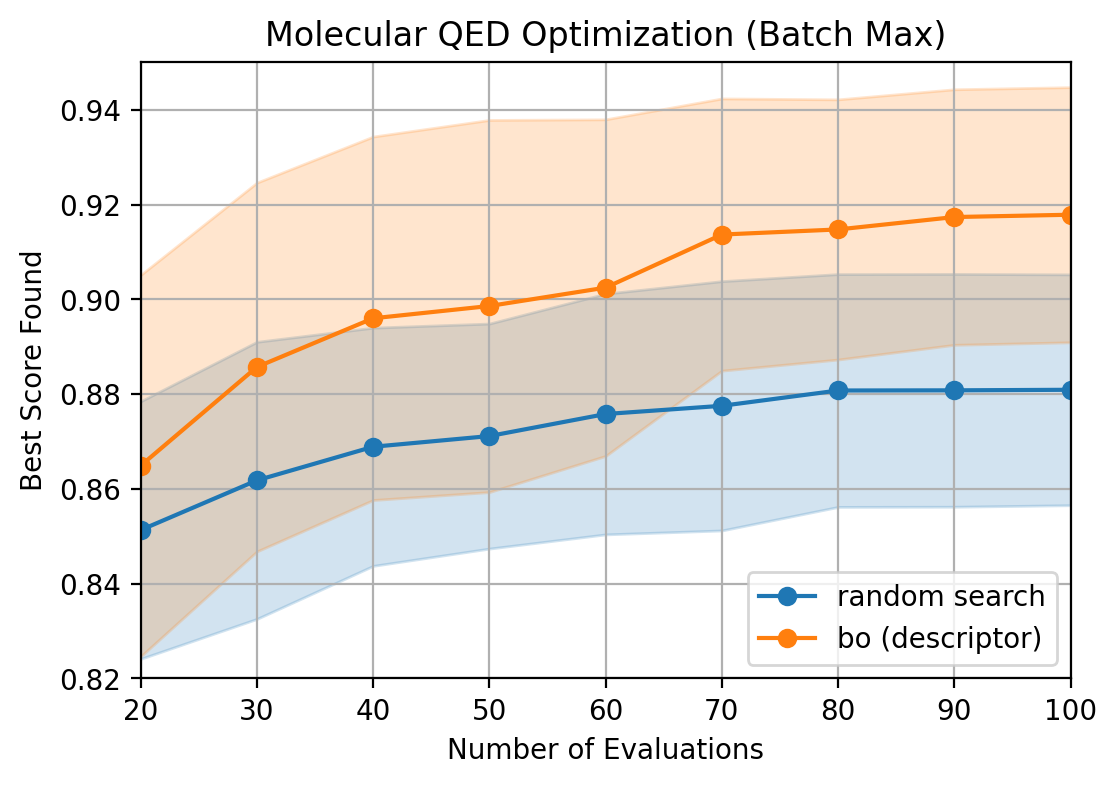

In [13]:
# plot the mean of best_ys across seeds, with shaded area representing the standard variance
plt.figure(figsize=(6, 4), dpi=200)
for method in runs.keys():
    all_runs = np.array([run[method] for run in scores])
    iterations = np.arange(0, all_runs.shape[1], 10) + 10
    all_runs = all_runs.reshape(16, -1, 10).max(axis=2)
    mean = np.mean(all_runs, axis=0)
    std = np.std(all_runs, axis=0)
    line, = plt.plot(iterations, mean, '-o', label=method)
    plt.fill_between(iterations, mean - std, mean + std, alpha=0.2, color=line.get_color())
plt.xlabel("Number of Evaluations")
plt.ylabel("Best Score Found")
plt.ylim(0.82, 0.95)
plt.xlim(20, 100)
plt.legend()
plt.grid()
plt.title("Molecular QED Optimization (Batch Max)")
plt.savefig("examples/Molecule/QED_bo_vs_rs.pdf")
plt.show()